## Read the data and preprocess it. 

- Read the spacial and temportal feature dataset.
- Filter and select the dataset within our space of consideration.
- shift coordinates for plotting.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
import contextily as ctx
import pandas as pd
import numpy as np
import seaborn as sns
from math import sqrt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_predict
import seaborn as sns
from imblearn.over_sampling import SMOTE
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score 
from pyproj import Transformer
from haversine import haversine
from gurobipy import Model, GRB, quicksum, max_, min_, abs_
from scipy.spatial.distance import cdist
import os
# os.makedirs('Figures',exist_ok = True)
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
pd.options.mode.chained_assignment = None 
pd.set_option('display.max_rows', None)
import ast

## Preparation for Stochastic Maximum Coverage Problem

In [2]:
df_EV_existing_two_idx = pd.read_csv("df_EV_existing_two_idx.csv")
df_EV_existing_two_idx.set_index(['Index', 'SubIndex'], inplace=True)
df_EV_existing_two_idx['center'] = df_EV_existing_two_idx['center'].apply(ast.literal_eval)

df_EV_predict_two_idx = pd.read_csv("df_EV_predict_two_idx.csv")
df_EV_predict_two_idx.set_index(['PrimaryIndex', 'Hour'], inplace=True)
df_EV_predict_two_idx['center'] = df_EV_predict_two_idx['center'].apply(ast.literal_eval)


In [3]:
pri_idx_df_EV_predict = df_EV_predict_two_idx.index.get_level_values(0).unique().to_numpy()
pri_idx_df_EV_existing = df_EV_existing_two_idx.index.get_level_values(0).unique().to_numpy()

In [4]:
average_EVdem_by_index = df_EV_existing_two_idx.groupby("Index")["trainingEVdemand"].mean()

In [5]:
c1 = {}
transformer = Transformer.from_crs("epsg:3857", "epsg:4326", always_xy=True)
for i in pri_idx_df_EV_predict:
    for j in pri_idx_df_EV_predict:
        point_i = transformer.transform(df_EV_predict_two_idx.loc[(i, 0), "center"][1], df_EV_predict_two_idx.loc[(i, 0), "center"][0])
        point_j = transformer.transform(df_EV_predict_two_idx.loc[(j, 0), "center"][1], df_EV_predict_two_idx.loc[(j, 0), "center"][0])
        c1[i, j] = haversine(point_i, point_j)
#         print(point_i, point_j)

In [6]:
max(c1.values())

70.83033679052825

In [7]:
c2 = {}
transformer = Transformer.from_crs("epsg:3857", "epsg:4326", always_xy=True)
for i in pri_idx_df_EV_predict:
    for j in pri_idx_df_EV_existing:
        point_i = transformer.transform(df_EV_predict_two_idx.loc[(i, 0), "center"][1], df_EV_predict_two_idx.loc[(i, 0), "center"][0])
        point_j = transformer.transform(df_EV_existing_two_idx.loc[(j, 0), "center"][1], df_EV_existing_two_idx.loc[(j, 0), "center"][0])
        c2[i, j] = haversine(point_i, point_j)

In [8]:
max(c2.values())

69.84963596928796

In [9]:
total_indices = list(set(pri_idx_df_EV_existing).union(set(pri_idx_df_EV_predict)))
c3 = {}

for idx in total_indices:
    if idx < 1000:
        c3[idx] = df_EV_predict_two_idx.loc[idx, 0]["avg_volt"]
    else:
        c3[idx] = df_EV_existing_two_idx.loc[idx, 0]["avg_volt"]

In [10]:
max(c3.values())

1.0461932821198872

In [11]:
df_EV_predict_two_idx

EV_demand_pred                                     center  \
PrimaryIndex Hour                                                              
0            0           0.031656  (-10926430.816974942, 3547773.7526442404)   
             1           0.031656  (-10926430.816974942, 3547773.7526442404)   
             2           0.031656  (-10926430.816974942, 3547773.7526442404)   
             3           0.031656  (-10926430.816974942, 3547773.7526442404)   
             4           0.031656  (-10926430.816974942, 3547773.7526442404)   
             5           0.031656  (-10926430.816974942, 3547773.7526442404)   
             6           0.031656  (-10926430.816974942, 3547773.7526442404)   
             7           0.031656  (-10926430.816974942, 3547773.7526442404)   
             8           0.031656  (-10926430.816974942, 3547773.7526442404)   
             9           0.031656  (-10926430.816974942, 3547773.7526442404)   
             10          0.031656  (-10926430.816974942, 3547773.7526442404)   
             11          0.031656  (-10926430.816974942, 3547773.7526442404)   
             12          0.031656  (-10926430.816974942, 3547773.7526442404)   
             13          0.031656  (-10926430.816974942, 3547773.7526442404)   
             14          0.031656  (-10926430.816974942, 3547773.7526442404)   
             15          0.031656  (-10926430.816974942, 3547773.7526442404)   
             16          0.031656  (-10926430.816974942, 3547773.7526442404)   
             17          0.031656  (-10926430.816974942, 3547773.7526442404)   
             18          0.031656  (-10926430.816974942, 3547773.7526442404)   
             19          0.031656  (-10926430.816974942, 3547773.7526442404)   
             20          0.031656  (-10926430.816974942, 3547773.7526442404)   
             21          0.031656  (-10926430.816974942, 3547773.7526442404)   
             22          0.031656  (-10926430.816974942, 3547773.7526442404)   
             23          0.031656  (-10926430.816974942, 3547773.7526442404)   
1            0           0.773395  (-10926430.816974942, 3560373.7526442404)   
             1           0.773395  (-10926430.816974942, 3560373.7526442404)   
             2           0.773395  (-10926430.816974942, 3560373.7526442404)   
             3           0.773395  (-10926430.816974942, 3560373.7526442404)   
             4           0.773395  (-10926430.816974942, 3560373.7526442404)   
             5           0.773395  (-10926430.816974942, 3560373.7526442404)   
             6           1.155043  (-10926430.816974942, 3560373.7526442404)   
             7           1.106854  (-10926430.816974942, 3560373.7526442404)   
             8           1.042252  (-10926430.816974942, 3560373.7526442404)   
             9           1.034423  (-10926430.816974942, 3560373.7526442404)   
             10          1.052136  (-10926430.816974942, 3560373.7526442404)   
             11          1.163214  (-10926430.816974942, 3560373.7526442404)   
             12          1.391481  (-10926430.816974942, 3560373.7526442404)   
             13          0.773395  (-10926430.816974942, 3560373.7526442404)   
             14          0.773395  (-10926430.816974942, 3560373.7526442404)   
             15          0.773395  (-10926430.816974942, 3560373.7526442404)   
             16          0.773395  (-10926430.816974942, 3560373.7526442404)   
             17          0.773395  (-10926430.816974942, 3560373.7526442404)   
             18          0.773395  (-10926430.816974942, 3560373.7526442404)   
             19          0.773395  (-10926430.816974942, 3560373.7526442404)   
             20          0.773395  (-10926430.816974942, 3560373.7526442404)   
             21          0.773395  (-10926430.816974942, 3560373.7526442404)   
             22          0.773395  (-10926430.816974942, 3560373.7526442404)   
             23          0.773395  (-10926430.816974942, 3560373.7526442404)   
8            0     

In [12]:
df_EV_existing_two_idx

ChargerNumber  trainingEVdemand  \
Index SubIndex                                    
1000  0                  16.0          6.000000   
      1                  16.0          7.142857   
      2                  16.0          6.571429   
      3                  16.0          6.142857   
      4                  16.0          3.857143   
      5                  16.0          2.285714   
      6                  16.0          2.571429   
      7                  16.0          4.000000   
      8                  16.0          5.142857   
      9                  16.0          4.714286   
      10                 16.0          4.000000   
      11                 16.0          3.000000   
      12                 16.0          3.142857   
      13                 16.0          3.000000   
      14                 16.0          3.571429   
      15                 16.0          2.857143   
      16                 16.0          3.571429   
      17                 16.0          4.857143   
      18                 16.0          5.000000   
      19                 16.0          5.142857   
      20                 16.0          3.857143   
      21                 16.0          3.857143   
      22                 16.0          4.142857   
      23                 16.0          6.571429   
1001  0                  10.0          1.714286   
      1                  10.0          1.142857   
      2                  10.0          1.142857   
      3                  10.0          0.571429   
      4                  10.0          1.285714   
      5                  10.0          1.428571   
      6                  10.0          1.285714   
      7                  10.0          1.142857   
      8                  10.0          0.571429   
      9                  10.0          0.571429   
      10                 10.0          1.428571   
      11                 10.0          2.571429   
      12                 10.0          4.428571   
      13                 10.0          4.428571   
      14                 10.0          4.142857   
      15                 10.0          2.857143   
      16                 10.0          2.857143   
      17                 10.0          2.285714   
      18                 10.0          1.142857   
      19                 10.0          0.857143   
      20                 10.0          1.571429   
      21                 10.0          2.000000   
      22                 10.0          2.857143   
      23                 10.0          3.000000   
1002  0                   3.0          0.714286   
      1                   3.0          0.714286   
      2                   3.0          0.285714   
      3                   3.0          0.857143   
      4                   3.0          0.428571   
      5                   3.0          0.428571   
      6                   3.0          0.571429   
      7                   3.0          0.428571   
      8                   3.0          0.285714   
      9                   3.0          0.571429   
      10                  3.0          0.571429   
      11                  3.0          0.571429   
      12                  3.0          0.428571   
      13                  3.0          0.142857   
      14                  3.0          0.428571   
      15                  3.0          1.142857   
      16                  3.0          1.142857   
      17                  3.0          0.857143   
      18                  3.0          0.285714   
      19                  3.0          0.428571   
      20                  3.0          0.714286   
      21                  3.0          0.714286   
      22                  3.0          0.714286   
      23                  3.0          0.571429   
1003  0                   8.0          1.000000   
      1                   8.0          0.857143   
      2                   8.0          0.571429   
      3                   8.0          1.000000   
      4                   8.0         

# Model and Solve: Stochastic Max Covering Problem

# Optimization problem (phase II): 

## Decision variables
1. Two sets of binary decision variables to determine whether location j is selected for establishing a new charging station or for expanding an existing one.
2. Two sets of integer decision variables to determine the number of ports to introduce at newly established charging stations or to expand at existing stations.
3. Two sets of continuous decision variables to determine the number of EVs traveling to charging station j.


## Objective function 

##### Multi-objective objective function
1. Minimize the establishment cost, including land, parking, and infrastructure expenses.
2. Minimize the cost per charging port.
3. Minimize the waiting time at charging stations.
4. Minimize the travel distance for EV users.
5. Select power grid nodes that maximize the minimum voltage level, ensuring grid stability.

## Sets of Constraints 
1. *First constraint set* is to minimize the maximum traffic at any newly established charging station.
2. *Second constraint set* is to minimize the maximum traffic at an existing charging station.
3. *Third constraint set* includes five constraints that ensure the EV charging demand at a newly established charging station j is met while respecting its capacity limits (number of ports).
4. *Fourth constraint set* includes five constraints that ensure the EV charging demand at an existing charging station j is met while staying within the capacity limits of the newly added ports.
5. *Fifth constraint set* ensures that the number of newly established chargers remains within the allowed maximum limit.
6. *Sixth constraint set*  limits the expansion of existing chargers to the allowed maximum number of additional ports.


In [13]:
A1 = [(edge[0], edge[1]) for edge in c1.keys()] # Candidate to another candidate
A2 = [(edge[0], edge[1]) for edge in c2.keys()] # Candidate to another EV charger available
T = range(24)

In [14]:
# max_capacity_exist_charger = 5 # 3
# max_travel_dist = 1000
# max_capacity_cand_charger = 6 #######################################
# max_chargers = 30 
# max_exist_chargers = 50
# run_time = 60 * 3

In [15]:
hourly_demand_sum = df_EV_predict_two_idx.groupby(level='Hour')["EV_demand_pred"].sum().to_dict()
hourly_demand_sum

{0: 63.26455103,
 1: 62.18528133,
 2: 60.9812337,
 3: 61.2103668,
 4: 61.567423240000004,
 5: 64.36624053,
 6: 68.93815607,
 7: 72.37313804,
 8: 73.05592652,
 9: 73.48915708,
 10: 74.80307117,
 11: 76.06850941,
 12: 76.79625113,
 13: 77.52747991,
 14: 78.18677497,
 15: 75.96696163,
 16: 76.74955177,
 17: 76.44677502,
 18: 76.594165,
 19: 76.62082563999999,
 20: 74.88706844,
 21: 71.47391968,
 22: 68.81755131,
 23: 65.40723559}

In [16]:
def OR_model(max_capacity_exist_charger, max_capacity_cand_charger, installment_cost, max_travel_dist, max_chargers, max_exist_chargers, run_time, budget, coeff_demand):
    
    ################# callback function to track feasibility ######################
    
    objective_values = []
    feasibility_values = []
    iteration_numbers = []

    def my_callback(model, where):
        if where == GRB.Callback.MIPNODE:
            try:
                obj = model.cbGet(GRB.Callback.MIPNODE_OBJBST)
                bound = model.cbGet(GRB.Callback.MIPNODE_OBJBND)
                nodecnt = model.cbGet(GRB.Callback.MIPNODE_NODCNT)

                objective_values.append(obj)
                feasibility_values.append(bound - obj)  # smaller difference means closer to optimal
                iteration_numbers.append(nodecnt)
            except:
                pass

    ################# model and variable definition ######################

    mdl = Model()
    Cand_len = pri_idx_df_EV_predict
    EV_avail_len = pri_idx_df_EV_existing # all the available chargers

    total_indices = list(set(pri_idx_df_EV_existing).union(set(pri_idx_df_EV_predict)))

    x1 = mdl.addVars(Cand_len, vtype = GRB.BINARY) # new charger stations (from candidate pts)
    x2 = mdl.addVars(EV_avail_len, vtype = GRB.BINARY) # existing charger station, port added.

    Capacity1 = mdl.addVars(Cand_len, vtype = GRB.INTEGER)
    Capacity2 = mdl.addVars(EV_avail_len, vtype = GRB.INTEGER)

    y1 = mdl.addVars(A1, T, vtype = GRB.CONTINUOUS)
    y2 = mdl.addVars(A2, T, vtype = GRB.CONTINUOUS)

    w1 = mdl.addVars(Cand_len, vtype = GRB.CONTINUOUS)
    w2 = mdl.addVars(EV_avail_len, vtype = GRB.CONTINUOUS)
    
    M = mdl.addVars(total_indices, T, vtype = GRB.CONTINUOUS) 

#     max_var = mdl_2.addVar(vtype=GRB.CONTINUOUS)

    ########################## objective function ##################################

    mdl.modelSense = GRB.MINIMIZE 

    mdl.setObjective(quicksum(installment_cost / 5000 * x1[j] for j in Cand_len) + quicksum(1 * x2[j] for j in EV_avail_len)
                     + quicksum(3200/10 * Capacity1[j] for j in Cand_len) + quicksum(3200/10 * Capacity2[j] for j in EV_avail_len)
#                      + 0 * max_var  
                     + (1 / len(T)) * (quicksum(c1[i, j] * y1[i, j, t] for i, j in A1 for t in T) 
                                       + quicksum(c2[i, j] * y2[i, j, t] for i, j in A2 for t in T))
                     - 1 * (quicksum(c3[j] * x1[j] for j in Cand_len) + quicksum(c3[j] * x2[j] for j in EV_avail_len))
                    )

    ########################### constraints #################################
    
    #### budget constraints #####
    
    mdl.addConstr(installment_cost * quicksum(x1[j] for j in Cand_len) + 3200 * quicksum(Capacity1[j] for j in Cand_len)
                  + 0 * quicksum(x2[j] for j in EV_avail_len) + 3200 * quicksum(Capacity2[j] for j in EV_avail_len) <= budget)
    


    # The following set of constraint is to satisfy the EV charging demands (provided the EV is within the allowed distance).
    for t in T:
        for i in Cand_len:
            mdl.addConstr(quicksum(y1[i, j, t] for j in Cand_len if c1[i, j] < max_travel_dist) 
                            + quicksum(y2[i, j, t] for j in EV_avail_len if c2[i, j] < max_travel_dist) >= 
                            coeff_demand * df_EV_predict_two_idx.loc[(i, t), "EV_demand_pred"])      
            
    for t in T:
        for i in Cand_len:
            mdl.addConstr(quicksum(y1[i, j, t] for j in Cand_len if c1[i, j] < max_travel_dist) 
                            + quicksum(y2[i, j, t] for j in EV_avail_len if c2[i, j] < max_travel_dist) + M[i, t] == 
                            df_EV_predict_two_idx.loc[(i, t), "EV_demand_pred"]) 

    # The following five set of constraints are to satisfy the EV charging demands at
    # a newly established charging station j, provided it is within capacity limits (number of ports).   

    for t in T:
        for j in Cand_len:
            mdl.addConstr(quicksum(y1[i, j, t] for i in Cand_len) <= w1[j])     

    for j in Cand_len:
        mdl.addConstr(w1[j] <= Capacity1[j])

    for j in Cand_len:
        mdl.addConstr(w1[j] <= max_capacity_cand_charger * x1[j])

    for j in Cand_len:
        mdl.addConstr(w1[j] >= Capacity1[j] - max_capacity_cand_charger * (1 - x1[j]))    

    for j in Cand_len:
        mdl.addConstr(Capacity1[j] <= max_capacity_cand_charger)

    # The following five set of constraints are to satisfy the EV charging demands at
    # an existing charging station j, provided it is within capacity limits of newly established ports.   

    for t in T:
        for j in EV_avail_len:
            mdl.addConstr(quicksum(y2[i, j, t] for i in Cand_len) <= w2[j])

    for j in EV_avail_len:
        mdl.addConstr(w2[j] <= Capacity2[j])

    for j in EV_avail_len:
        mdl.addConstr(w2[j] <= max_capacity_exist_charger * x2[j])

    for j in EV_avail_len:
        mdl.addConstr(w2[j] >= Capacity2[j] - max_capacity_exist_charger * (1 - x2[j]))

    for j in EV_avail_len:
        mdl.addConstr(Capacity2[j] <= max_capacity_exist_charger)    

    # The following set of constraint is to limit the newly established chargers are within the allowed maximum chargers to establish.
    mdl.addConstr(quicksum(x1[j] for j in Cand_len) <= max_chargers)

    # The following set of constraint is to limit the expasion of existing chargers within the allowed maximum chargers to expand.
    mdl.addConstr(quicksum(x2[j] for j in EV_avail_len) <= max_exist_chargers)

    mdl.Params.TimeLimit = run_time

    # mdl_2.Params.LogToConsole = 0

    #     mdl_2.Params.MIPFocus = 1

    mdl.optimize(my_callback)

    print("Objective function value:", mdl.objVal)

    Hourly_waiting_time = {}

    for t in T:
        Hourly_waiting_time[t] = sum(M[i, t].x for i in total_indices)

    active_assign_cand1 = {}
    active_assign_cand2 = {}

    for t in T:
        active_assign_cand1[t] = [(a[0], a[1]) for a in A1 if y1[a[0], a[1], t].x > 0]
        active_assign_cand2[t] = [(a[0], a[1]) for a in A2 if y2[a[0], a[1], t].x > 0]

    actively_opened_stn1 = [i for i in Cand_len if Capacity1[i].x > 0.5] 
    actively_opened_stn2 = [i for i in EV_avail_len if Capacity2[i].x > 0.5] 

    Capacity_of_opened_stn1 = {}
    Capacity_of_opened_stn2 = {}
    extra_ports_added2 = {}

    Capacity_of_opened_stn1 = {i: Capacity1[i].x for i in Cand_len if Capacity1[i].x > 0.5}
    extra_ports_added2 = {i: Capacity2[i].x for i in EV_avail_len if Capacity2[i].x > 0.5}
    Capacity_of_opened_stn2 = {i: df_EV_existing_two_idx.loc[(i, 0), "ChargerNumber"] 
                                 + extra_ports_added2[i] for i in extra_ports_added2.keys()}

    print(len(actively_opened_stn1))
    print(len(actively_opened_stn2))
    
    ########################### plot infeasibility and objective #################################

    fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

    # Subplot 1: Objective Value
    axs[0].plot(objective_values, label='Objective Function Value', color='blue')
    axs[0].set_xlabel('Iterations')
    axs[0].set_ylabel('Objective Function Value')
    axs[0].legend()
    axs[0].grid(True)

    # Subplot 2: Feasibility Gap
    axs[1].plot(feasibility_values, label='Feasibility Gap', color='green')
    axs[1].set_xlabel('Iterations')
    axs[1].set_ylabel('Feasibility Gap')
    axs[1].legend()
    axs[1].grid(True)

    # Main title
    fig.suptitle('Objective and Feasibility Evolution')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    return actively_opened_stn1, actively_opened_stn2, Capacity_of_opened_stn1, extra_ports_added2, Capacity_of_opened_stn2, Hourly_waiting_time, active_assign_cand1, active_assign_cand2

In [17]:
def plot_ev_charger_results(pri_idx_df_EV_existing,
                            Hourly_waiting_time, hourly_demand_sum,
                            df_EV_predict_two_idx, df_EV_existing_two_idx,
                            actively_opened_stn1, actively_opened_stn2,
                            save_path_map):
        
                       
    # Waiting time plot
    hours = list(hourly_demand_sum.keys())
    demand_values = [hourly_demand_sum[h] for h in hours]
    unsat_values = [Hourly_waiting_time[h] for h in hours]

    plt.figure(figsize=(10, 6))
    bar_width = 0.4
    x = range(len(hours))

    plt.bar(x, demand_values, width=bar_width, color='blue', label='Hourly Demand')
    plt.bar(x, unsat_values, width=bar_width, color='red', label='Unsatisfied Demand')
    plt.xticks(x, hours)
    plt.xlabel("Hour")
    plt.ylabel("Demand")
    plt.title("Hourly Demand vs Unsatisfied Demand")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Map Plot
#     gdf_grid = gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:3857")
#     charger_geometries1 = [Point(df_EV_predict_two_idx.loc[(i, 0), "center"]) for i in actively_opened_stn1]
#     charger_geometries2 = [Point(df_EV_existing_two_idx.loc[(i, 0), "center"]) for i in actively_opened_stn2]
#     final_charger1 = gpd.GeoDataFrame(geometry=charger_geometries1)
#     final_charger2 = gpd.GeoDataFrame(geometry=charger_geometries2)

#     fig, ax = plt.subplots(figsize=(12, 12))
#     gdf_GPrim_coord['geometry_init'].plot(ax=ax, color='orange', label='Power_grid_buses', marker='.', markersize=9)
#     gdf_grid.boundary.plot(ax=ax, color="gray", linewidth=1.5, alpha=0.99)

#     existing_coords = df_EV_existing_two_idx["center"].tolist()
#     x_vals0 = [pt[0] for pt in existing_coords]
#     y_vals0 = [pt[1] for pt in existing_coords]
#     ax.scatter(x_vals0, y_vals0, color='blue', marker='o', s=30, label='Existing Chargers')

#     candidate_coords = df_EV_predict_two_idx["center"].tolist()
#     x_vals1 = [pt[0] for pt in candidate_coords]
#     y_vals1 = [pt[1] for pt in candidate_coords]
#     ax.scatter(x_vals1, y_vals1, color='red', marker='^', s=60, label='Charger Candidate Location')

#     x_coords1 = [pt.x for pt in final_charger1.geometry]
#     y_coords1 = [pt.y for pt in final_charger1.geometry]
#     ax.scatter(x_coords1, y_coords1, label='Newly Opened EV Chargers',
#                edgecolor='black', facecolor='none', s=180, linewidths=3)

#     x_coords2 = [pt.x for pt in final_charger2.geometry]
#     y_coords2 = [pt.y for pt in final_charger2.geometry]
#     ax.scatter(x_coords2, y_coords2, label='Ports Added at Existing EV Chargers',
#                edgecolor='magenta', facecolor='none', s=180, linewidths=3)

#     ax.set_xlim([minx - 1800, maxx + 3600])
#     ax.set_ylim([miny - 1800, maxy + 2700])
#     ctx.add_basemap(ax, crs=gdf_set_1.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
#     plt.xlabel("Longitude (meters)", fontsize=18)
#     plt.ylabel("Latitude (meters)", fontsize=18)
#     plt.legend(fontsize=18, loc='lower right', bbox_to_anchor=(1.02, 0.75))
#     plt.xticks(fontsize=18)
#     plt.yticks(fontsize=18)
#     plt.savefig(save_path_map, bbox_inches='tight')
#     plt.show()

In [18]:
budget = 1000000 # 10 M budget! 
run_time = 60 * 10

# max_capacity_cand_charger = 2
# max_capacity_exist_charger = 6

Set parameter Username

--------------------------------------------
--------------------------------------------

Academic license - for non-commercial use only - expires 2025-06-07
Set parameter TimeLimit to value 600
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD Ryzen Threadripper PRO 5995WX 64-Cores, instruction set [SSE2|AVX|AVX2]
Thread count: 64 physical cores, 128 logical processors, using up to 32 threads

Optimize a model with 14951 rows, 632277 columns and 1878074 nonzeros
Model fingerprint: 0x737e05e1
Variable types: 631415 continuous, 862 integer (431 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+04]
  Objective range  [6e-03, 3e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [3e-02, 1e+06]
Presolve removed 1872 rows and 10344 columns (presolve time = 5s) ...
Presolve removed 1872 rows and 10344 columns
Presolve time: 7.80s
Presolved: 13079 rows, 621933 columns, 1255503 nonzeros
Variable types: 6

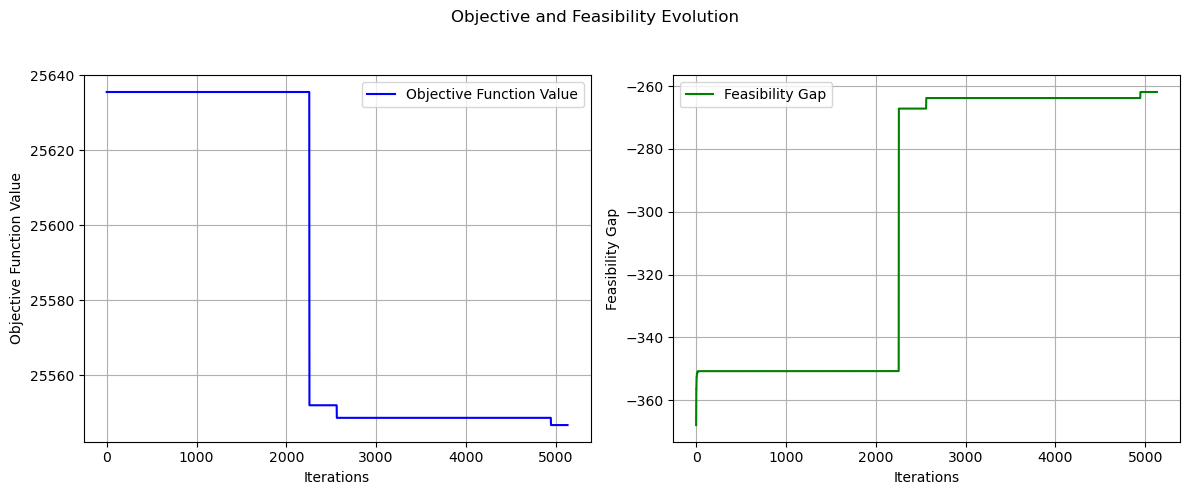

8
28


In [19]:
max_capacity_exist_charger = 6 # 3
max_travel_dist = 6500
max_capacity_cand_charger = 2 #######################################
max_chargers = 30 
max_exist_chargers = 50
# run_time = 60 * 15
installment_cost_0 = 50000
coeff_demand_0 = 1

[actively_opened_stn1_0, actively_opened_stn2_0, Capacity_of_opened_stn1_0, extra_ports_added2_0, Capacity_of_opened_stn2_0, Hourly_waiting_time_0, active_assign_cand1_0, active_assign_cand2_0] = OR_model(max_capacity_exist_charger,
                                                                                                                                                               max_capacity_cand_charger, installment_cost_0,
                                                                                                                                                               max_travel_dist, 
                                                                                                                                                               max_chargers, 
                                                                                                                                                               max_exist_chargers, 
                                                                                                                                                               run_time, budget, coeff_demand_0)
if len(actively_opened_stn1_0) > 0:
    df_actively_opened_stn1_0 = pd.DataFrame(actively_opened_stn1_0)
    df_actively_opened_stn1_0.columns = ['pri_idx_df_EV_predict']
    capacity_series = pd.Series(Capacity_of_opened_stn1_0, name='capacity')
    capacity_df = capacity_series.reset_index()
    capacity_df.columns = ['pri_idx_df_EV_predict', 'capacity']
    df_actively_opened_stn1_0 = df_actively_opened_stn1_0.merge(capacity_df, on='pri_idx_df_EV_predict', how='left')
    long_list = []
    lat_list = []
    for i in df_actively_opened_stn1_0['pri_idx_df_EV_predict']:
        center = df_EV_predict_two_idx.loc[(i, 0), "center"]
    #     point = transformer.transform(center[1], center[0])  # transformer(long, lat)
        point = center
        long_list.append(point[0])
        lat_list.append(point[1])
    df_actively_opened_stn1_0['X'] = long_list
    df_actively_opened_stn1_0['Y'] = lat_list
    df_actively_opened_stn1_0.to_excel('Results4/newly_opened_chargers_set0.xlsx', index = False)
print(len(actively_opened_stn1_0))

if len(actively_opened_stn2_0) > 0:
    df_actively_opened_stn2_0 = pd.DataFrame(actively_opened_stn2_0)
    df_actively_opened_stn2_0.columns = ['pri_idx_df_EV_existing']
    capacity_series = pd.Series(extra_ports_added2_0, name='capacity')
    capacity_df = capacity_series.reset_index()
    capacity_df.columns = ['pri_idx_df_EV_existing', 'capacity']
    df_actively_opened_stn2_0 = df_actively_opened_stn2_0.merge(capacity_df, on='pri_idx_df_EV_existing', how='left')
    long_list = []
    lat_list = []
    for i in df_actively_opened_stn2_0['pri_idx_df_EV_existing']:
        center = df_EV_existing_two_idx.loc[(i, 0), "center"]
    #     point = transformer.transform(center[1], center[0])  # transformer(long, lat)
        point = center
        long_list.append(point[0])
        lat_list.append(point[1])
    df_actively_opened_stn2_0['X'] = long_list
    df_actively_opened_stn2_0['Y'] = lat_list
    df_actively_opened_stn2_0.to_excel('Results4/Expanded_existing_chargers_set0.xlsx', index = False)
print(len(actively_opened_stn2_0)) 

average unsatisfied demand :  0.0



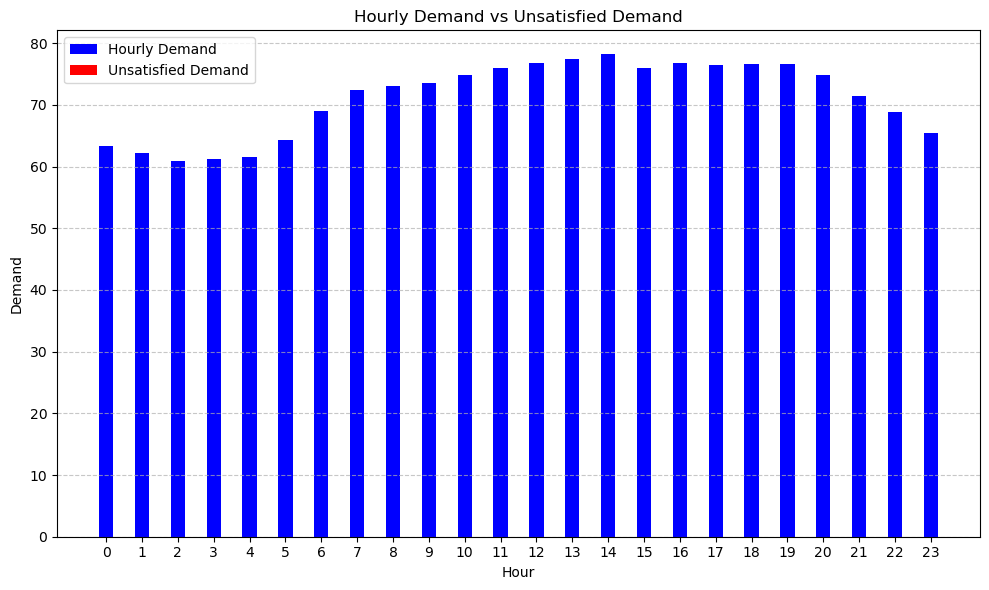

In [20]:
save_path_map = "Results4/results_OR1_set0.pdf"

print("average unsatisfied demand : ", np.average(list(Hourly_waiting_time_0.values())))
print()

plot_ev_charger_results(pri_idx_df_EV_existing,
                        Hourly_waiting_time_0, hourly_demand_sum,
                        df_EV_predict_two_idx, df_EV_existing_two_idx,
                        actively_opened_stn1_0, actively_opened_stn2_0,
                        save_path_map)

# max_capacity_cand_charger = 4
# max_capacity_exist_charger = 5

Set parameter TimeLimit to value 600
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD Ryzen Threadripper PRO 5995WX 64-Cores, instruction set [SSE2|AVX|AVX2]
Thread count: 64 physical cores, 128 logical processors, using up to 32 threads

Optimize a model with 14951 rows, 632277 columns and 1878074 nonzeros
Model fingerprint: 0x0f9af01f
Variable types: 631415 continuous, 862 integer (431 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+04]
  Objective range  [6e-03, 3e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [3e-02, 1e+06]
Presolve removed 1872 rows and 10344 columns
Presolve time: 2.24s
Presolved: 13079 rows, 621933 columns, 1255503 nonzeros
Variable types: 620640 continuous, 1293 integer (431 binary)
Deterministic concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Root barrier log...

Ordering time: 0.50s

Barrier statistics:
 AA' NZ     : 5.318e+05
 Factor NZ  

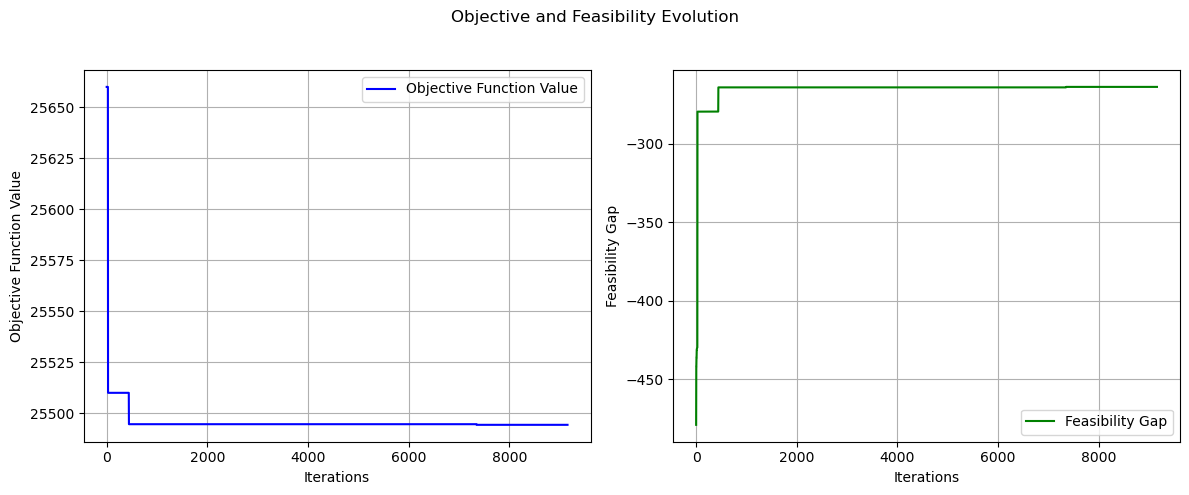

12
21


In [21]:
max_capacity_exist_charger = 5 # 3
max_travel_dist = 6500
max_capacity_cand_charger = 4 #######################################
max_chargers = 30 
max_exist_chargers = 50
# run_time = 60 * 15
installment_cost_1 = 50000
coeff_demand_1 = 1

[actively_opened_stn1_1, actively_opened_stn2_1, Capacity_of_opened_stn1_1, extra_ports_added2_1, Capacity_of_opened_stn2_1, Hourly_waiting_time_1, active_assign_cand1_1, active_assign_cand2_1] = OR_model(max_capacity_exist_charger,
                                                                                                                                                                    max_capacity_cand_charger, installment_cost_1,
                                                                                                                                                                    max_travel_dist, 
                                                                                                                                                                    max_chargers, 
                                                                                                                                                                    max_exist_chargers, 
                                                                                                                                                                    run_time, budget, coeff_demand_1)
if len(actively_opened_stn1_1) > 0:
    df_actively_opened_stn1_1 = pd.DataFrame(actively_opened_stn1_1)
    df_actively_opened_stn1_1.columns = ['pri_idx_df_EV_predict']
    capacity_series = pd.Series(Capacity_of_opened_stn1_1, name='capacity')
    capacity_df = capacity_series.reset_index()
    capacity_df.columns = ['pri_idx_df_EV_predict', 'capacity']
    df_actively_opened_stn1_1 = df_actively_opened_stn1_1.merge(capacity_df, on='pri_idx_df_EV_predict', how='left')
    long_list = []
    lat_list = []
    for i in df_actively_opened_stn1_1['pri_idx_df_EV_predict']:
        center = df_EV_predict_two_idx.loc[(i, 0), "center"]
    #     point = transformer.transform(center[1], center[0])  # transformer(long, lat)
        point = center
        long_list.append(point[0])
        lat_list.append(point[1])
    df_actively_opened_stn1_1['X'] = long_list
    df_actively_opened_stn1_1['Y'] = lat_list
    df_actively_opened_stn1_1.to_excel('Results4/newly_opened_chargers_set1.xlsx', index = False)
print(len(actively_opened_stn1_1))

if len(actively_opened_stn2_1) > 0:
    df_actively_opened_stn2_1 = pd.DataFrame(actively_opened_stn2_1)
    df_actively_opened_stn2_1.columns = ['pri_idx_df_EV_existing']
    capacity_series = pd.Series(extra_ports_added2_1, name='capacity')
    capacity_df = capacity_series.reset_index()
    capacity_df.columns = ['pri_idx_df_EV_existing', 'capacity']
    df_actively_opened_stn2_1 = df_actively_opened_stn2_1.merge(capacity_df, on='pri_idx_df_EV_existing', how='left')
    long_list = []
    lat_list = []
    for i in df_actively_opened_stn2_1['pri_idx_df_EV_existing']:
        center = df_EV_existing_two_idx.loc[(i, 0), "center"]
    #     point = transformer.transform(center[1], center[0])  # transformer(long, lat)
        point = center
        long_list.append(point[0])
        lat_list.append(point[1])
    df_actively_opened_stn2_1['X'] = long_list
    df_actively_opened_stn2_1['Y'] = lat_list
    df_actively_opened_stn2_1.to_excel('Results4/Expanded_existing_chargers_set1.xlsx', index = False)
print(len(actively_opened_stn2_1)) 

average unsatisfied demand :  0.0



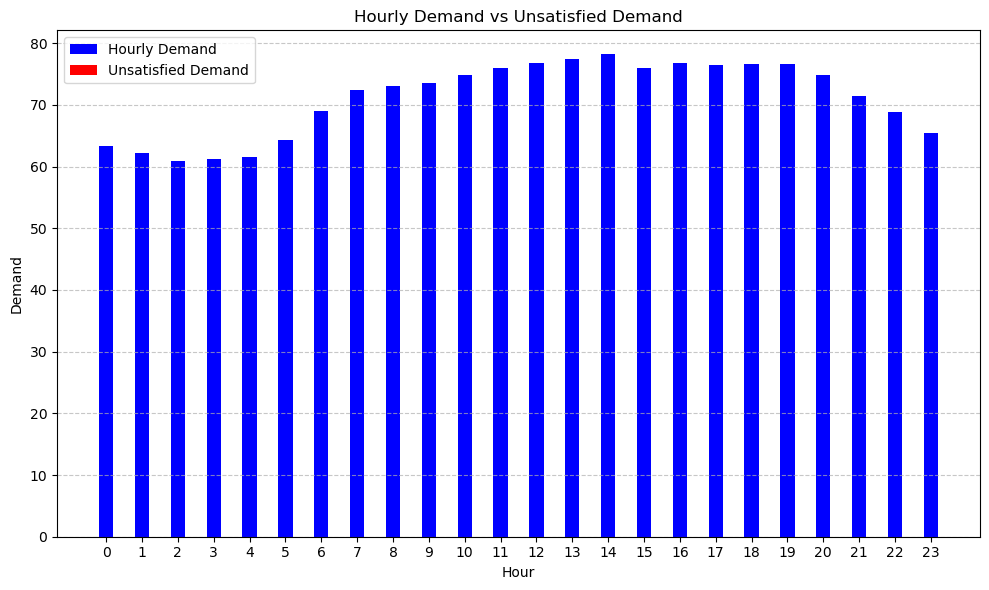

In [22]:
save_path_map = "Results4/results_OR1_set1.pdf"

print("average unsatisfied demand : ", np.average(list(Hourly_waiting_time_1.values())))
print()

plot_ev_charger_results(pri_idx_df_EV_existing,
                        Hourly_waiting_time_1, hourly_demand_sum,
                        df_EV_predict_two_idx, df_EV_existing_two_idx,
                        actively_opened_stn1_1, actively_opened_stn2_1,
                        save_path_map)

# max_capacity_cand_charger = 8
# max_capacity_exist_charger = 4

Set parameter TimeLimit to value 600
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD Ryzen Threadripper PRO 5995WX 64-Cores, instruction set [SSE2|AVX|AVX2]
Thread count: 64 physical cores, 128 logical processors, using up to 32 threads

Optimize a model with 14951 rows, 632277 columns and 1878074 nonzeros
Model fingerprint: 0x9d1b9986
Variable types: 631415 continuous, 862 integer (431 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+04]
  Objective range  [6e-03, 3e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [3e-02, 1e+06]
Presolve removed 1872 rows and 10344 columns (presolve time = 5s) ...
Presolve removed 1872 rows and 10344 columns
Presolve time: 6.58s
Presolved: 13079 rows, 621933 columns, 1255503 nonzeros
Variable types: 620640 continuous, 1293 integer (431 binary)
Deterministic concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Root barrier log...

Ordering

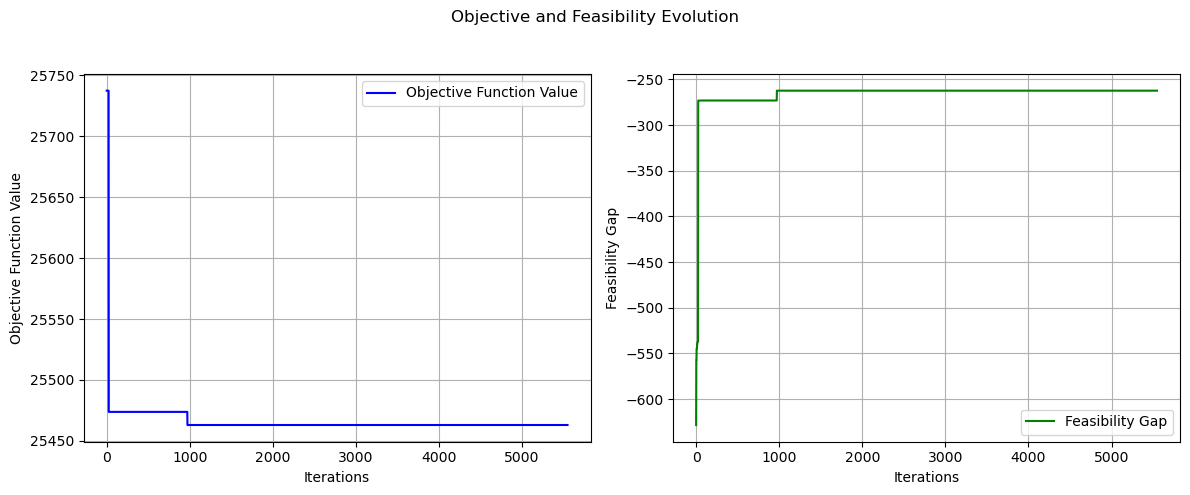

8
21


In [23]:
max_capacity_exist_charger = 4 # 3
max_travel_dist = 6500
max_capacity_cand_charger = 8 #######################################
max_chargers = 30 
max_exist_chargers = 50
# run_time = 60 * 15
installment_cost_2 = 50000
coeff_demand_2 = 1


[actively_opened_stn1_2, actively_opened_stn2_2, Capacity_of_opened_stn1_2, extra_ports_added2_2, Capacity_of_opened_stn2_2, Hourly_waiting_time_2, active_assign_cand1_2, active_assign_cand2_2] = OR_model(max_capacity_exist_charger,
                                                                                                                                                                    max_capacity_cand_charger, installment_cost_2,
                                                                                                                                                                    max_travel_dist, 
                                                                                                                                                                    max_chargers, 
                                                                                                                                                                    max_exist_chargers, 
                                                                                                                                                                    run_time, budget, coeff_demand_2)
if len(actively_opened_stn1_2) > 0:
    df_actively_opened_stn1_2 = pd.DataFrame(actively_opened_stn1_2)
    df_actively_opened_stn1_2.columns = ['pri_idx_df_EV_predict']
    capacity_series = pd.Series(Capacity_of_opened_stn1_2, name='capacity')
    capacity_df = capacity_series.reset_index()
    capacity_df.columns = ['pri_idx_df_EV_predict', 'capacity']
    df_actively_opened_stn1_2 = df_actively_opened_stn1_2.merge(capacity_df, on='pri_idx_df_EV_predict', how='left')
    long_list = []
    lat_list = []
    for i in df_actively_opened_stn1_2['pri_idx_df_EV_predict']:
        center = df_EV_predict_two_idx.loc[(i, 0), "center"]
    #     point = transformer.transform(center[1], center[0])  # transformer(long, lat)
        point = center
        long_list.append(point[0])
        lat_list.append(point[1])
    df_actively_opened_stn1_2['X'] = long_list
    df_actively_opened_stn1_2['Y'] = lat_list
    df_actively_opened_stn1_2.to_excel('Results4/newly_opened_chargers_set2.xlsx', index = False)
print(len(actively_opened_stn1_2))

if len(actively_opened_stn2_2) > 0:
    df_actively_opened_stn2_2 = pd.DataFrame(actively_opened_stn2_2)
    df_actively_opened_stn2_2.columns = ['pri_idx_df_EV_existing']
    capacity_series = pd.Series(extra_ports_added2_2, name='capacity')
    capacity_df = capacity_series.reset_index()
    capacity_df.columns = ['pri_idx_df_EV_existing', 'capacity']
    df_actively_opened_stn2_2 = df_actively_opened_stn2_2.merge(capacity_df, on='pri_idx_df_EV_existing', how='left')
    long_list = []
    lat_list = []
    for i in df_actively_opened_stn2_2['pri_idx_df_EV_existing']:
        center = df_EV_existing_two_idx.loc[(i, 0), "center"]
    #     point = transformer.transform(center[1], center[0])  # transformer(long, lat)
        point = center
        long_list.append(point[0])
        lat_list.append(point[1])
    df_actively_opened_stn2_2['X'] = long_list
    df_actively_opened_stn2_2['Y'] = lat_list
    df_actively_opened_stn2_2.to_excel('Results4/Expanded_existing_chargers_set2.xlsx', index = False)
print(len(actively_opened_stn2_2)) 

average unsatisfied demand :  0.0



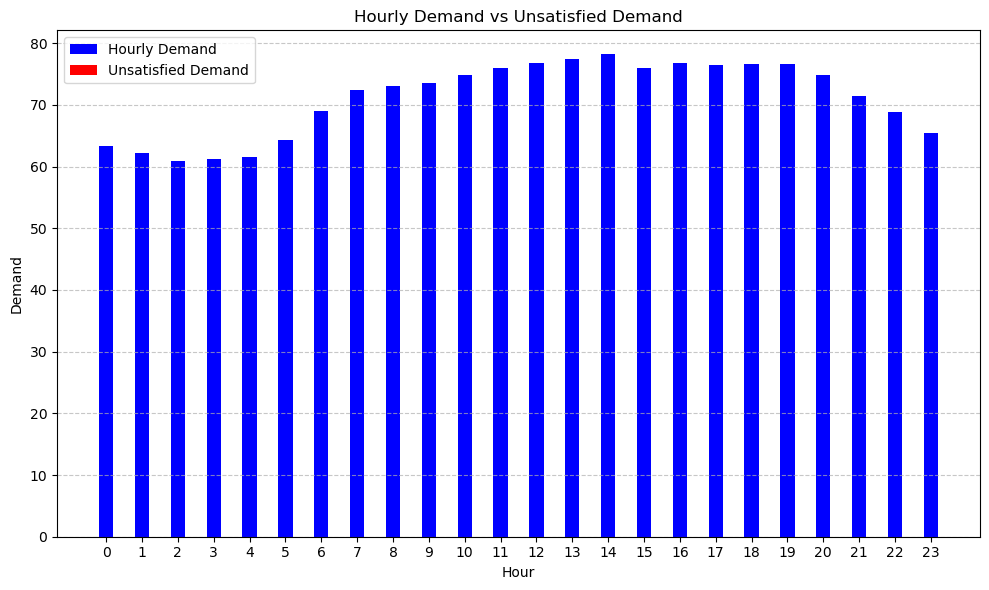

In [24]:
save_path_map = "Results4/results_OR1_set2.pdf"

print("average unsatisfied demand : ", np.average(list(Hourly_waiting_time_2.values())))
print()

plot_ev_charger_results(pri_idx_df_EV_existing,
                        Hourly_waiting_time_2, hourly_demand_sum,
                        df_EV_predict_two_idx, df_EV_existing_two_idx,
                        actively_opened_stn1_2, actively_opened_stn2_2,
                        save_path_map)

# max_capacity_cand_charger = 10
# max_capacity_exist_charger = 3

Set parameter TimeLimit to value 600
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD Ryzen Threadripper PRO 5995WX 64-Cores, instruction set [SSE2|AVX|AVX2]
Thread count: 64 physical cores, 128 logical processors, using up to 32 threads

Optimize a model with 14951 rows, 632277 columns and 1878074 nonzeros
Model fingerprint: 0x307bab36
Variable types: 631415 continuous, 862 integer (431 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+04]
  Objective range  [6e-03, 3e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [3e-02, 1e+06]
Presolve removed 1872 rows and 10344 columns
Presolve time: 2.61s
Presolved: 13079 rows, 621933 columns, 1255503 nonzeros
Variable types: 620640 continuous, 1293 integer (431 binary)
Deterministic concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Root barrier log...

Ordering time: 0.24s

Barrier statistics:
 AA' NZ     : 5.318e+05
 Factor NZ  

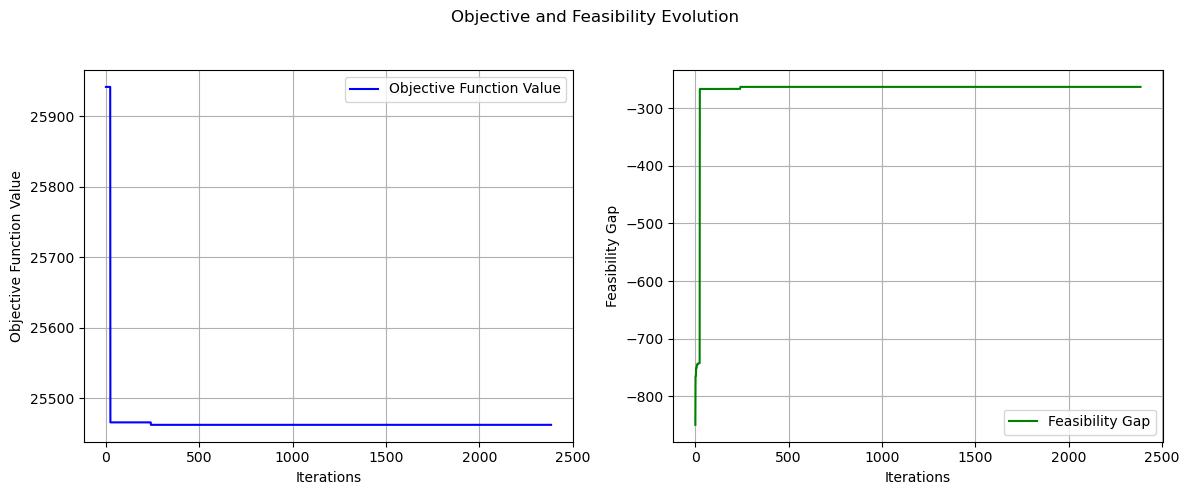

8
20


In [25]:
max_capacity_exist_charger = 3 # 3
max_travel_dist = 6500
max_capacity_cand_charger = 10 #######################################
max_chargers = 30 
max_exist_chargers = 50
# run_time = 60 * 15
installment_cost_3 = 50000
coeff_demand_3 = 1


[actively_opened_stn1_3, actively_opened_stn2_3, Capacity_of_opened_stn1_3, extra_ports_added2_3, Capacity_of_opened_stn2_3, Hourly_waiting_time_3, active_assign_cand1_3, active_assign_cand2_3] = OR_model(max_capacity_exist_charger,
                                                                                                                                                                    max_capacity_cand_charger, installment_cost_3,
                                                                                                                                                                    max_travel_dist, 
                                                                                                                                                                    max_chargers, 
                                                                                                                                                                    max_exist_chargers, 
                                                                                                                                                                    run_time, budget, coeff_demand_3)
if len(actively_opened_stn1_3) > 0:
    df_actively_opened_stn1_3 = pd.DataFrame(actively_opened_stn1_3)
    df_actively_opened_stn1_3.columns = ['pri_idx_df_EV_predict']
    capacity_series = pd.Series(Capacity_of_opened_stn1_3, name='capacity')
    capacity_df = capacity_series.reset_index()
    capacity_df.columns = ['pri_idx_df_EV_predict', 'capacity']
    df_actively_opened_stn1_3 = df_actively_opened_stn1_3.merge(capacity_df, on='pri_idx_df_EV_predict', how='left')
    long_list = []
    lat_list = []
    for i in df_actively_opened_stn1_3['pri_idx_df_EV_predict']:
        center = df_EV_predict_two_idx.loc[(i, 0), "center"]
    #     point = transformer.transform(center[1], center[0])  # transformer(long, lat)
        point = center
        long_list.append(point[0])
        lat_list.append(point[1])
    df_actively_opened_stn1_3['X'] = long_list
    df_actively_opened_stn1_3['Y'] = lat_list
    df_actively_opened_stn1_3.to_excel('Results4/newly_opened_chargers_set3.xlsx', index = False)
print(len(actively_opened_stn1_3))

if len(actively_opened_stn2_3) > 0:
    df_actively_opened_stn2_3 = pd.DataFrame(actively_opened_stn2_3)
    df_actively_opened_stn2_3.columns = ['pri_idx_df_EV_existing']
    capacity_series = pd.Series(extra_ports_added2_3, name='capacity')
    capacity_df = capacity_series.reset_index()
    capacity_df.columns = ['pri_idx_df_EV_existing', 'capacity']
    df_actively_opened_stn2_3 = df_actively_opened_stn2_3.merge(capacity_df, on='pri_idx_df_EV_existing', how='left')
    long_list = []
    lat_list = []
    for i in df_actively_opened_stn2_3['pri_idx_df_EV_existing']:
        center = df_EV_existing_two_idx.loc[(i, 0), "center"]
    #     point = transformer.transform(center[1], center[0])  # transformer(long, lat)
        point = center
        long_list.append(point[0])
        lat_list.append(point[1])
    df_actively_opened_stn2_3['X'] = long_list
    df_actively_opened_stn2_3['Y'] = lat_list
    df_actively_opened_stn2_3.to_excel('Results4/Expanded_existing_chargers_set3.xlsx', index = False)
print(len(actively_opened_stn2_3)) 

average unsatisfied demand :  0.0



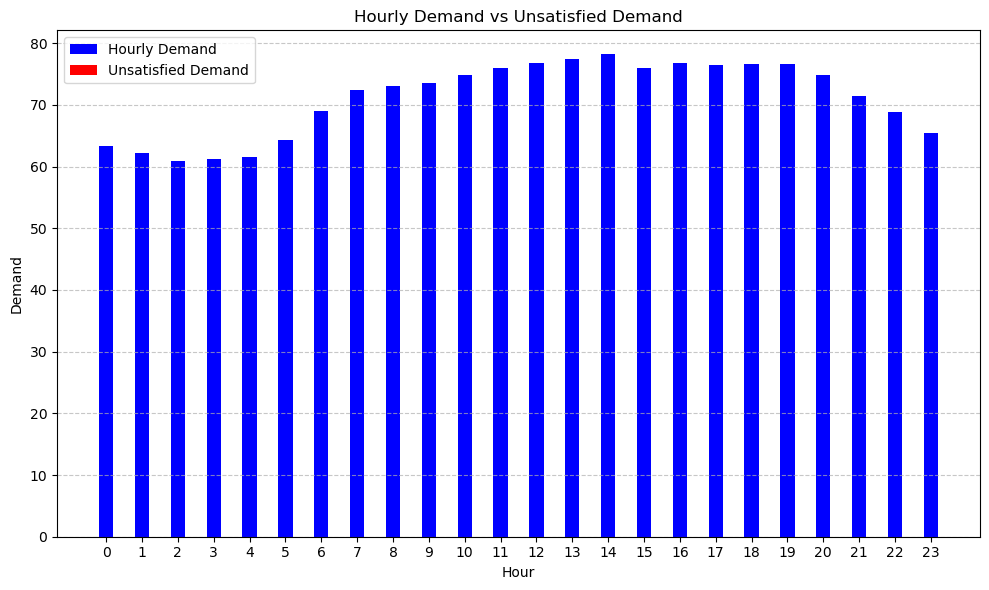

In [26]:
save_path_map = "Results4/results_OR1_set3.pdf"

print("average unsatisfied demand : ", np.average(list(Hourly_waiting_time_3.values())))
print()

plot_ev_charger_results(pri_idx_df_EV_existing,
                        Hourly_waiting_time_3, hourly_demand_sum,
                        df_EV_predict_two_idx, df_EV_existing_two_idx,
                        actively_opened_stn1_3, actively_opened_stn2_3,
                        save_path_map)

# max_capacity_cand_charger = 12
# max_capacity_exist_charger = 2

Set parameter TimeLimit to value 600
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD Ryzen Threadripper PRO 5995WX 64-Cores, instruction set [SSE2|AVX|AVX2]
Thread count: 64 physical cores, 128 logical processors, using up to 32 threads

Optimize a model with 14951 rows, 632277 columns and 1878074 nonzeros
Model fingerprint: 0x1faa11c1
Variable types: 631415 continuous, 862 integer (431 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+04]
  Objective range  [6e-03, 3e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [3e-02, 1e+06]
Presolve removed 1872 rows and 10344 columns (presolve time = 5s) ...
Presolve removed 1872 rows and 10344 columns
Presolve time: 9.45s
Presolved: 13079 rows, 621933 columns, 1255503 nonzeros
Variable types: 620640 continuous, 1293 integer (431 binary)
Deterministic concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Root barrier log...

Ordering

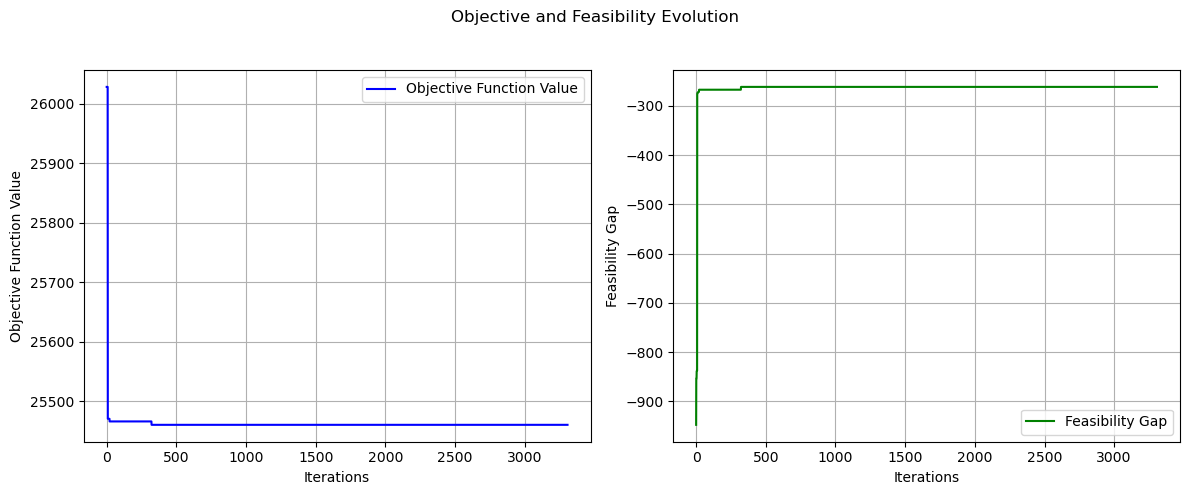

8
20


In [27]:
max_capacity_exist_charger = 2 # 3
max_travel_dist = 6500
max_capacity_cand_charger = 12 #######################################
max_chargers = 30 
max_exist_chargers = 50
# run_time = 60 * 15
installment_cost_4 = 50000
coeff_demand_4 = 1


[actively_opened_stn1_4, actively_opened_stn2_4, Capacity_of_opened_stn1_4, extra_ports_added2_4, Capacity_of_opened_stn2_4, Hourly_waiting_time_4, active_assign_cand1_4, active_assign_cand2_4] = OR_model(max_capacity_exist_charger,
                                                                                                                                                                    max_capacity_cand_charger, installment_cost_4,
                                                                                                                                                                    max_travel_dist, 
                                                                                                                                                                    max_chargers, 
                                                                                                                                                                    max_exist_chargers, 
                                                                                                                                                                    run_time, budget, coeff_demand_4)
if len(actively_opened_stn1_4) > 0:
    df_actively_opened_stn1_4 = pd.DataFrame(actively_opened_stn1_4)
    df_actively_opened_stn1_4.columns = ['pri_idx_df_EV_predict']
    capacity_series = pd.Series(Capacity_of_opened_stn1_4, name='capacity')
    capacity_df = capacity_series.reset_index()
    capacity_df.columns = ['pri_idx_df_EV_predict', 'capacity']
    df_actively_opened_stn1_4 = df_actively_opened_stn1_4.merge(capacity_df, on='pri_idx_df_EV_predict', how='left')
    long_list = []
    lat_list = []
    for i in df_actively_opened_stn1_4['pri_idx_df_EV_predict']:
        center = df_EV_predict_two_idx.loc[(i, 0), "center"]
    #     point = transformer.transform(center[1], center[0])  # transformer(long, lat)
        point = center
        long_list.append(point[0])
        lat_list.append(point[1])
    df_actively_opened_stn1_4['X'] = long_list
    df_actively_opened_stn1_4['Y'] = lat_list
    df_actively_opened_stn1_4.to_excel('Results4/newly_opened_chargers_set4.xlsx', index = False)
print(len(actively_opened_stn1_4))

if len(actively_opened_stn2_4) > 0:
    df_actively_opened_stn2_4 = pd.DataFrame(actively_opened_stn2_4)
    df_actively_opened_stn2_4.columns = ['pri_idx_df_EV_existing']
    capacity_series = pd.Series(extra_ports_added2_4, name='capacity')
    capacity_df = capacity_series.reset_index()
    capacity_df.columns = ['pri_idx_df_EV_existing', 'capacity']
    df_actively_opened_stn2_4 = df_actively_opened_stn2_4.merge(capacity_df, on='pri_idx_df_EV_existing', how='left')
    long_list = []
    lat_list = []
    for i in df_actively_opened_stn2_4['pri_idx_df_EV_existing']:
        center = df_EV_existing_two_idx.loc[(i, 0), "center"]
    #     point = transformer.transform(center[1], center[0])  # transformer(long, lat)
        point = center
        long_list.append(point[0])
        lat_list.append(point[1])
    df_actively_opened_stn2_4['X'] = long_list
    df_actively_opened_stn2_4['Y'] = lat_list
    df_actively_opened_stn2_4.to_excel('Results4/Expanded_existing_chargers_set4.xlsx', index = False)
print(len(actively_opened_stn2_4)) 

average unsatisfied demand :  0.0



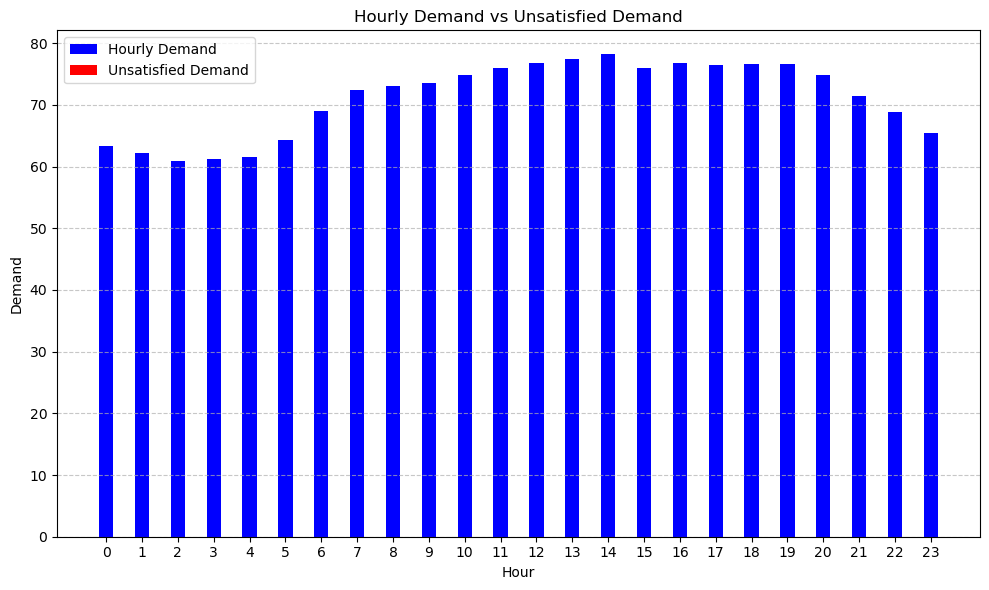

In [28]:
save_path_map = "Results4/results_OR1_set4.pdf"

print("average unsatisfied demand : ", np.average(list(Hourly_waiting_time_4.values())))
print()

plot_ev_charger_results(pri_idx_df_EV_existing,
                        Hourly_waiting_time_4, hourly_demand_sum,
                        df_EV_predict_two_idx, df_EV_existing_two_idx,
                        actively_opened_stn1_4, actively_opened_stn2_4,
                        save_path_map)

# max_capacity_cand_charger = 14
# max_capacity_exist_charger = 1

Set parameter TimeLimit to value 600
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD Ryzen Threadripper PRO 5995WX 64-Cores, instruction set [SSE2|AVX|AVX2]
Thread count: 64 physical cores, 128 logical processors, using up to 32 threads

Optimize a model with 14951 rows, 632277 columns and 1878074 nonzeros
Model fingerprint: 0x53bb704d
Variable types: 631415 continuous, 862 integer (431 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+04]
  Objective range  [6e-03, 3e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [3e-02, 1e+06]
Presolve removed 2632 rows and 10733 columns
Presolve time: 3.76s
Presolved: 12319 rows, 621544 columns, 1253612 nonzeros
Variable types: 620640 continuous, 904 integer (784 binary)
Deterministic concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Root barrier log...

Ordering time: 0.27s

Barrier statistics:
 AA' NZ     : 5.318e+05
 Factor NZ  :

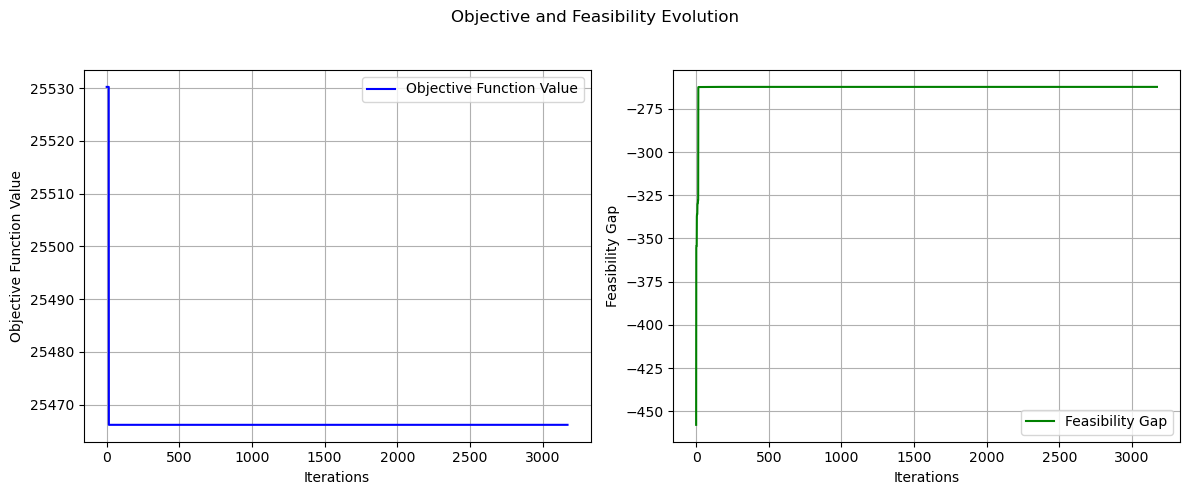

8
24


In [29]:
max_capacity_exist_charger = 1 # 3
max_travel_dist = 6500
max_capacity_cand_charger = 14 #######################################
max_chargers = 30 
max_exist_chargers = 50
# run_time = 60 * 15
installment_cost_5 = 50000
coeff_demand_5 = 1


[actively_opened_stn1_5, actively_opened_stn2_5, Capacity_of_opened_stn1_5, extra_ports_added2_5, Capacity_of_opened_stn2_5, Hourly_waiting_time_5, active_assign_cand1_5, active_assign_cand2_5] = OR_model(max_capacity_exist_charger,
                                                                                                                                                                    max_capacity_cand_charger, installment_cost_5,
                                                                                                                                                                    max_travel_dist, 
                                                                                                                                                                    max_chargers, 
                                                                                                                                                                    max_exist_chargers, 
                                                                                                                                                                    run_time, budget, coeff_demand_5)
if len(actively_opened_stn1_5) > 0:
    df_actively_opened_stn1_5 = pd.DataFrame(actively_opened_stn1_5)
    df_actively_opened_stn1_5.columns = ['pri_idx_df_EV_predict']
    capacity_series = pd.Series(Capacity_of_opened_stn1_5, name='capacity')
    capacity_df = capacity_series.reset_index()
    capacity_df.columns = ['pri_idx_df_EV_predict', 'capacity']
    df_actively_opened_stn1_5 = df_actively_opened_stn1_5.merge(capacity_df, on='pri_idx_df_EV_predict', how='left')
    long_list = []
    lat_list = []
    for i in df_actively_opened_stn1_5['pri_idx_df_EV_predict']:
        center = df_EV_predict_two_idx.loc[(i, 0), "center"]
    #     point = transformer.transform(center[1], center[0])  # transformer(long, lat)
        point = center
        long_list.append(point[0])
        lat_list.append(point[1])
    df_actively_opened_stn1_5['X'] = long_list
    df_actively_opened_stn1_5['Y'] = lat_list
    df_actively_opened_stn1_5.to_excel('Results4/newly_opened_chargers_set5.xlsx', index = False)
print(len(actively_opened_stn1_5))

if len(actively_opened_stn2_5) > 0:
    df_actively_opened_stn2_5 = pd.DataFrame(actively_opened_stn2_5)
    df_actively_opened_stn2_5.columns = ['pri_idx_df_EV_existing']
    capacity_series = pd.Series(extra_ports_added2_5, name='capacity')
    capacity_df = capacity_series.reset_index()
    capacity_df.columns = ['pri_idx_df_EV_existing', 'capacity']
    df_actively_opened_stn2_5 = df_actively_opened_stn2_5.merge(capacity_df, on='pri_idx_df_EV_existing', how='left')
    long_list = []
    lat_list = []
    for i in df_actively_opened_stn2_5['pri_idx_df_EV_existing']:
        center = df_EV_existing_two_idx.loc[(i, 0), "center"]
    #     point = transformer.transform(center[1], center[0])  # transformer(long, lat)
        point = center
        long_list.append(point[0])
        lat_list.append(point[1])
    df_actively_opened_stn2_5['X'] = long_list
    df_actively_opened_stn2_5['Y'] = lat_list
    df_actively_opened_stn2_5.to_excel('Results4/Expanded_existing_chargers_set5.xlsx', index = False)
print(len(actively_opened_stn2_5)) 

average unsatisfied demand :  0.0



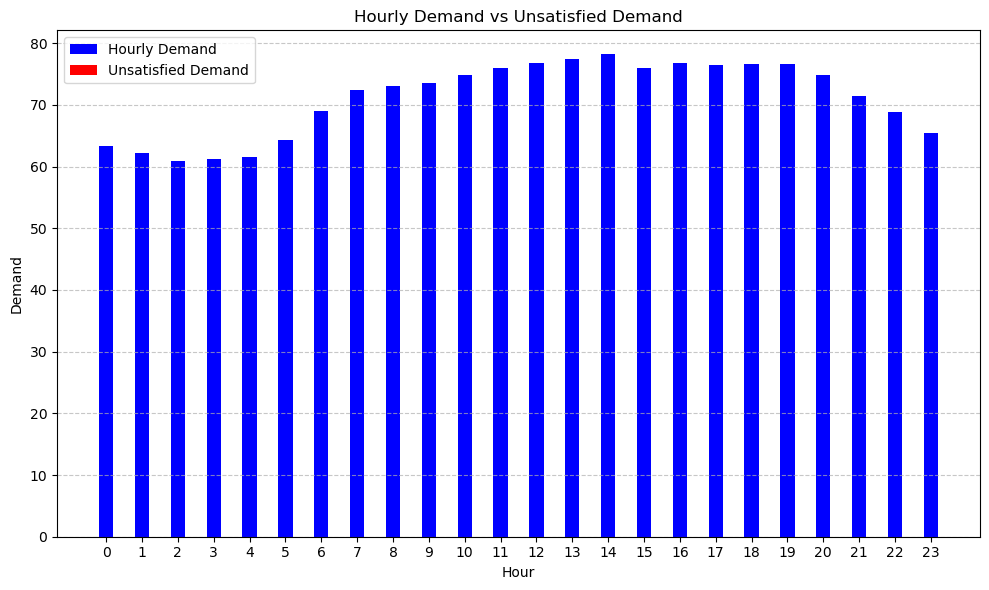

In [30]:
save_path_map = "Results4/results_OR1_set5.pdf"

print("average unsatisfied demand : ", np.average(list(Hourly_waiting_time_5.values())))
print()

plot_ev_charger_results(pri_idx_df_EV_existing,
                        Hourly_waiting_time_5, hourly_demand_sum,
                        df_EV_predict_two_idx, df_EV_existing_two_idx,
                        actively_opened_stn1_5, actively_opened_stn2_5,
                        save_path_map)

# max_capacity_cand_charger = 16
# max_capacity_exist_charger = 0

Set parameter TimeLimit to value 600
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD Ryzen Threadripper PRO 5995WX 64-Cores, instruction set [SSE2|AVX|AVX2]
Thread count: 64 physical cores, 128 logical processors, using up to 32 threads

Optimize a model with 14951 rows, 632277 columns and 1877332 nonzeros
Model fingerprint: 0xf25fe5a4
Variable types: 631415 continuous, 862 integer (431 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+04]
  Objective range  [6e-03, 3e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [3e-02, 1e+06]
Presolve removed 10448 rows and 545344 columns
Presolve time: 1.14s
Presolved: 4503 rows, 86933 columns, 261593 nonzeros
Variable types: 86400 continuous, 533 integer (413 binary)
Found heuristic solution: objective 27029.652087
Deterministic concurrent LP optimizer: primal and dual simplex
Showing primal log only...

Concurrent spin time: 0.01s

Solved with primal simplex

Root relaxation

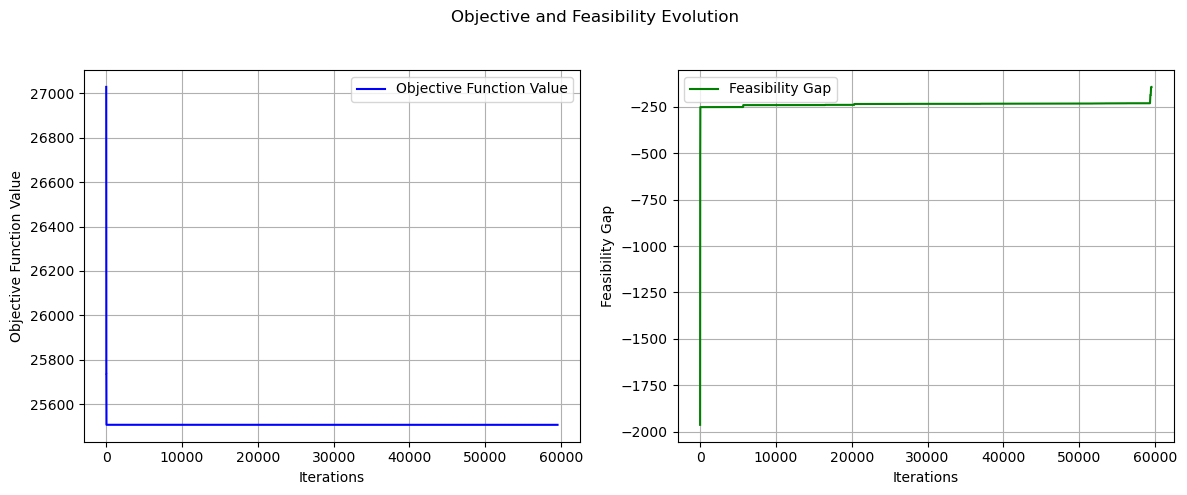

14
0


In [31]:
max_capacity_exist_charger = 0 # 3
max_travel_dist = 6500
max_capacity_cand_charger = 16 #######################################
max_chargers = 30 
max_exist_chargers = 50
# run_time = 60 * 15
installment_cost_6 = 50000
coeff_demand_6 = 1


[actively_opened_stn1_6, actively_opened_stn2_6, Capacity_of_opened_stn1_6, extra_ports_added2_6, Capacity_of_opened_stn2_6, Hourly_waiting_time_6, active_assign_cand1_6, active_assign_cand2_6] = OR_model(max_capacity_exist_charger,
                                                                                                                                                                    max_capacity_cand_charger, installment_cost_6,
                                                                                                                                                                    max_travel_dist, 
                                                                                                                                                                    max_chargers, 
                                                                                                                                                                    max_exist_chargers, 
                                                                                                                                                                    run_time, budget, coeff_demand_6)
if len(actively_opened_stn1_6) > 0:    
    df_actively_opened_stn1_6 = pd.DataFrame(actively_opened_stn1_6)
    df_actively_opened_stn1_6.columns = ['pri_idx_df_EV_predict']
    capacity_series = pd.Series(Capacity_of_opened_stn1_6, name='capacity')
    capacity_df = capacity_series.reset_index()
    capacity_df.columns = ['pri_idx_df_EV_predict', 'capacity']
    df_actively_opened_stn1_6 = df_actively_opened_stn1_6.merge(capacity_df, on='pri_idx_df_EV_predict', how='left')
    long_list = []
    lat_list = []
    for i in df_actively_opened_stn1_6['pri_idx_df_EV_predict']:
        center = df_EV_predict_two_idx.loc[(i, 0), "center"]
    #     point = transformer.transform(center[1], center[0])  # transformer(long, lat)
        point = center
        long_list.append(point[0])
        lat_list.append(point[1])
    df_actively_opened_stn1_6['X'] = long_list
    df_actively_opened_stn1_6['Y'] = lat_list
    df_actively_opened_stn1_6.to_excel('Results4/newly_opened_chargers_set6.xlsx', index = False)    
print(len(actively_opened_stn1_6))

if len(actively_opened_stn2_6) > 0:
    df_actively_opened_stn2_2 = pd.DataFrame(actively_opened_stn2_2)
    df_actively_opened_stn2_2.columns = ['pri_idx_df_EV_existing']
    capacity_series = pd.Series(Capacity_of_opened_stn2_2, name='capacity')
    capacity_df = capacity_series.reset_index()
    capacity_df.columns = ['pri_idx_df_EV_existing', 'capacity']
    df_actively_opened_stn2_2 = df_actively_opened_stn2_2.merge(capacity_df, on='pri_idx_df_EV_existing', how='left')
    long_list = []
    lat_list = []
    for i in df_actively_opened_stn2_2['pri_idx_df_EV_existing']:
        center = df_EV_existing_two_idx.loc[(i, 0), "center"]
        point = transformer.transform(center[1], center[0])  # transformer(long, lat)
        long_list.append(point[0])
        lat_list.append(point[1])
    df_actively_opened_stn2_2['lat'] = lat_list
    df_actively_opened_stn2_2['long'] = long_list
    df_actively_opened_stn2_2.to_excel('Results4/Expanded_existing_chargers_set6.xlsx', index = False)
print(len(actively_opened_stn2_6)) 

average unsatisfied demand :  0.0



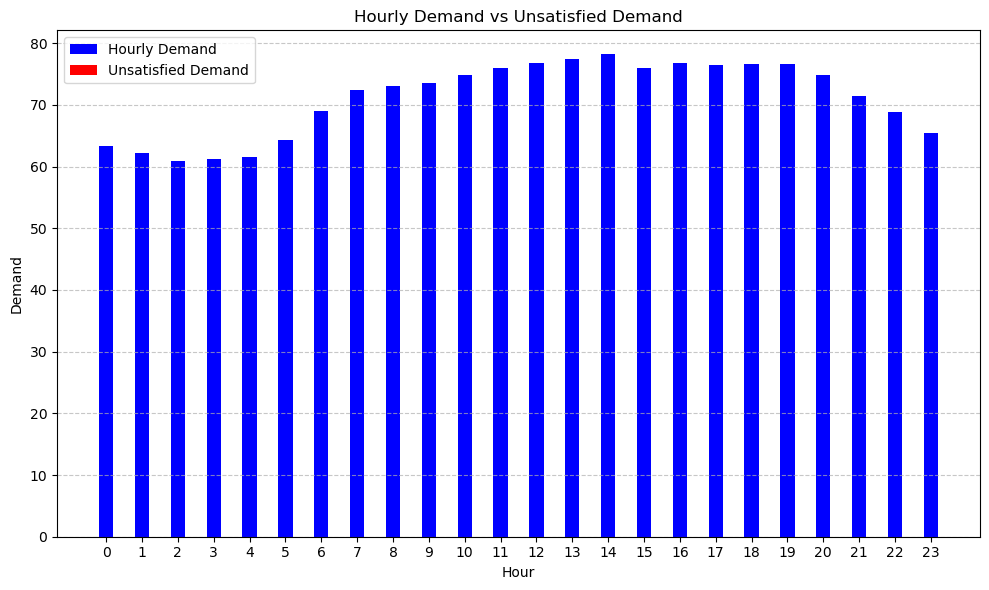

In [32]:
save_path_map = "Results4/results_OR1_set6.pdf"

print("average unsatisfied demand : ", np.average(list(Hourly_waiting_time_6.values())))
print()

plot_ev_charger_results(pri_idx_df_EV_existing,
                        Hourly_waiting_time_6, hourly_demand_sum,
                        df_EV_predict_two_idx, df_EV_existing_two_idx,
                        actively_opened_stn1_6, actively_opened_stn2_6,
                        save_path_map)

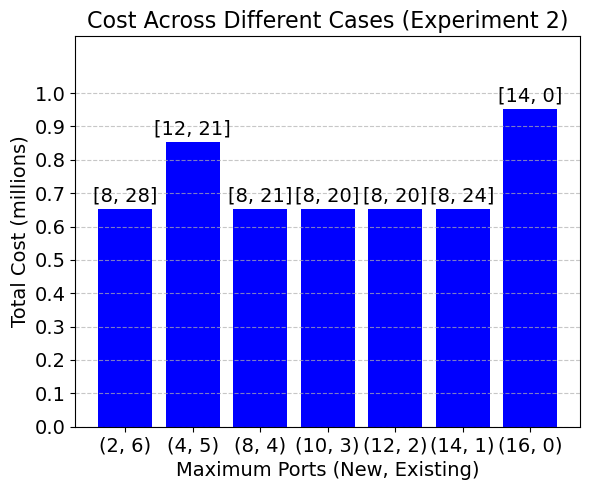

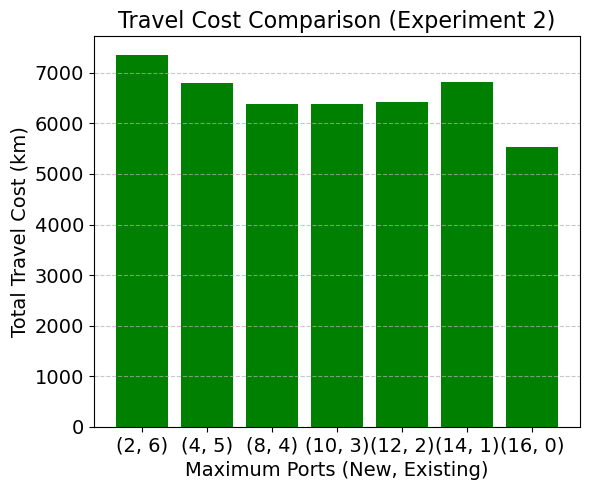

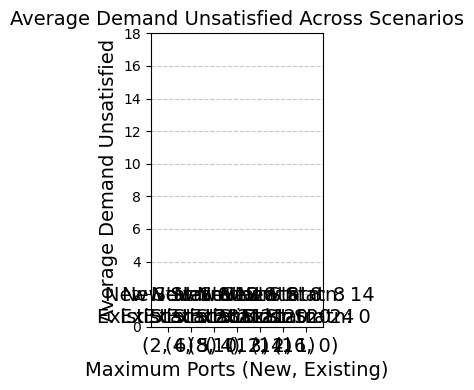

In [48]:
# Define custom x-axis labels
x_labels = [(2, 6), (4, 5), (8, 4), (10, 3), (12, 2), (14, 1), (16, 0)]

bars = []
bars_origin = []
capacity_counts = []  # Store [new_charging_stations, charging_stations_extended] for each bar

for i in range(7):
    installment_cost = globals()[f"installment_cost_{i}"]
    capacity_dict = globals()[f"Capacity_of_opened_stn1_{i}"]
    extra_ports = globals()[f"extra_ports_added2_{i}"]

    capacity_sum = sum(capacity_dict.values()) + sum(extra_ports.values())
    num_sites = len(capacity_dict)

    bar_val = 3200 * capacity_sum + num_sites * installment_cost
    bars_origin.append(bar_val) 
    bars.append(bar_val/1000000)

    capacity_counts.append([len(capacity_dict), len(extra_ports)])

# Plot Total Cost
plt.figure(figsize=(6, 5))
bars_pos = range(7)
plt.bar(bars_pos, bars, color='blue')
plt.xticks(bars_pos, x_labels, fontsize=14)
plt.xlabel("Maximum Ports (New, Existing)", fontsize=14)
plt.ylabel("Total Cost (millions)", fontsize=14)
plt.ylim(0, 1.17)
plt.title("Cost Across Different Cases (Experiment 2)", fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add multi-line annotations on top of each bar
for idx, (bar_height, counts) in enumerate(zip(bars, capacity_counts)):
    annotation = f"[{counts[0]}, {counts[1]}]"
    height_label = f"{bar_height:.2f}M"
    plt.text(idx, bar_height + max(bars) * 0.01, annotation,
             ha='center', va='bottom', fontsize=14, color='black')
    # plt.text(idx, bar_height, height_label,
    #          ha='center', va='bottom', fontsize=11, color='black', weight='bold')
    
y_ticks = np.arange(0, 1.01, 0.1)  # ticks from 0 to 1 with step 0.1
plt.yticks(y_ticks, [f"{y:.1f}" for y in y_ticks], fontsize=14)


plt.tight_layout()
# plt.show()
plt.savefig("Expt2_est_cost.pdf", format='pdf', bbox_inches='tight')

# Plot Travel Cost
Travel_cost = {}
for i in range(7):
    Travel_cost[i] = 0
    active_assign_cand1 = globals()[f"active_assign_cand1_{i}"]
    active_assign_cand2 = globals()[f"active_assign_cand2_{i}"]

    for t in T:
        for value in active_assign_cand1[t]:
            Travel_cost[i] += c1[value]
        for value in active_assign_cand2[t]:
            Travel_cost[i] += c2[value]

plt.figure(figsize=(6, 5))
plt.bar(range(7), Travel_cost.values(), color='green')
plt.yticks(fontsize = 14)
plt.xticks(range(7), x_labels, fontsize=14)
plt.xlabel("Maximum Ports (New, Existing)", fontsize=14)
plt.ylabel("Total Travel Cost (km)", fontsize=14)
plt.title("Travel Cost Comparison (Experiment 2)", fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.show()
plt.savefig("Expt2_travel_cost.pdf", format='pdf', bbox_inches='tight')

# Compute average waiting times
average_waiting_times = [
    np.average(list(Hourly_waiting_time_0.values())),
    np.average(list(Hourly_waiting_time_1.values())),
    np.average(list(Hourly_waiting_time_2.values())),
    np.average(list(Hourly_waiting_time_3.values())),
    np.average(list(Hourly_waiting_time_4.values())),
    np.average(list(Hourly_waiting_time_5.values())),
    np.average(list(Hourly_waiting_time_6.values())),
]

bars = average_waiting_times  # Using average waiting times as bar heights

# Unsatisfied demand plot
plt.figure(figsize=(3, 4))
plt.bar(range(7), average_waiting_times, color='skyblue')
plt.xticks(range(7), x_labels, fontsize=14)
plt.xlabel("Maximum Ports (New, Existing)", fontsize=14)
plt.ylabel('Average Demand Unsatisfied', fontsize=14)
plt.ylim(0, 18)
plt.title('Average Demand Unsatisfied Across Scenarios', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add multi-line annotations on top of each bar
for idx, (bar_height, counts) in enumerate(zip(bars, capacity_counts)):
    annotation = f"New Statn: {counts[0]}\nExist Statn: {counts[1]}"
    plt.text(idx, bar_height + max(bars) * 0.02, annotation,
             ha='center', va='bottom', fontsize=14, color='black')

plt.tight_layout()
plt.show()